# Lab 4 - Training of Binary Classifiers

In this exercise, we use a breast cancer dataset (see https://www.kaggle.com/uciml/breast-cancer-wisconsin-data). All columns in this dataset are numerical, except the `diagnosis` column, which is ordinal. Each example is a breast cancer case with a diagnosis of either M (malignant) or B (benign).

We train and compare two binary classifiers using proper model selection methodology.

We will:
- Tune hyperparameters using 10-fold cross-validation on the training set,
- Compare models using multiple evaluation metrics,
- Select the best-performing model based on cross-validated F1 score,
- Evaluate the final model once on a held-out test set.

The test set is used only at the final stage to estimate generalisation performance.

In [1]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler, RobustScaler, FunctionTransformer
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    cross_val_predict,
)
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    auc,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
)
from sklearn import set_config
import pickle
import matplotlib.pyplot as plt
%matplotlib inline


## 1. EDA - Exploratory Data Analysis

In [2]:
df = pd.read_csv("./bcwd.csv")
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
df.tail()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
564,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
568,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,...,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039


In [4]:
df['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

First of all let's check for missing values and outliers.

In [5]:
df.isna().sum()

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

There are no missing values. Let's check the boxplots of the numerical columns for outliers. We will do this in three slices.

In [6]:
df.loc[:,'radius_mean':'fractal_dimension_mean'].describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440


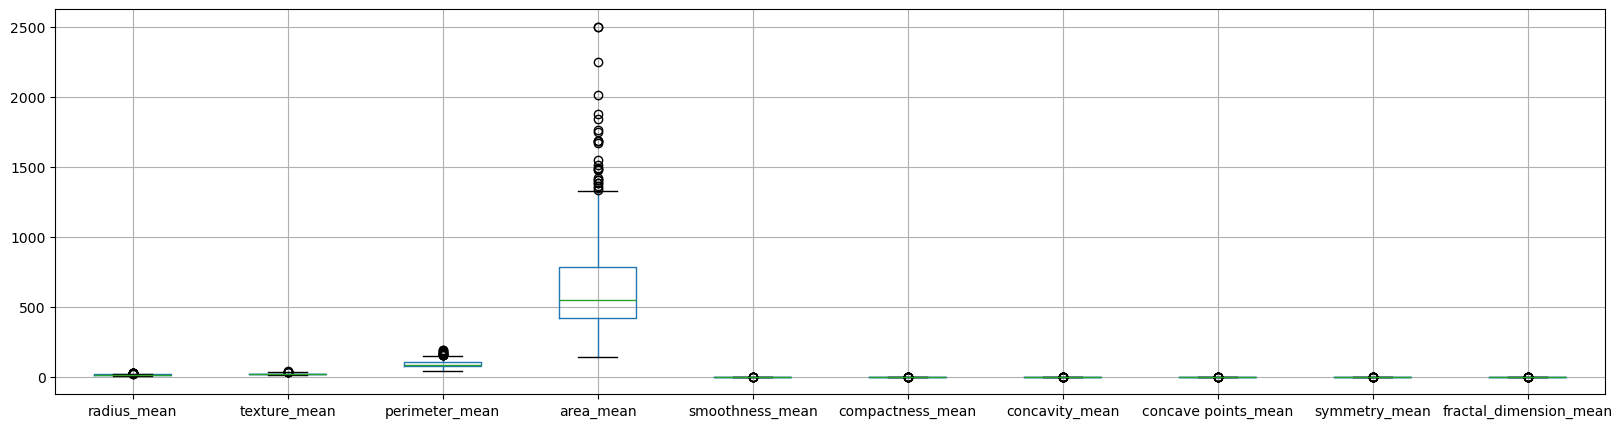

In [7]:
df.loc[:,'radius_mean':'fractal_dimension_mean'].boxplot(figsize=(20,5))
plt.show()

In [8]:
df.loc[:,'radius_se':'fractal_dimension_se'].describe()

,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,0.405172,1.216853,2.866059,40.337079,0.007041,0.025478,0.031894,0.011796,0.020542,0.003795
std,0.277313,0.551648,2.021855,45.491006,0.003003,0.017908,0.030186,0.006170,0.008266,0.002646
min,0.111500,0.360200,0.757000,6.802000,0.001713,0.002252,0.000000,0.000000,0.007882,0.000895
25%,0.232400,0.833900,1.606000,17.850000,0.005169,0.013080,0.015090,0.007638,0.015160,0.002248
50%,0.324200,1.108000,2.287000,24.530000,0.006380,0.020450,0.025890,0.010930,0.018730,0.003187
75%,0.478900,1.474000,3.357000,45.190000,0.008146,0.032450,0.042050,0.014710,0.023480,0.004558
max,2.873000,4.885000,21.980000,542.200000,0.031130,0.135400,0.396000,0.052790,0.078950,0.029840


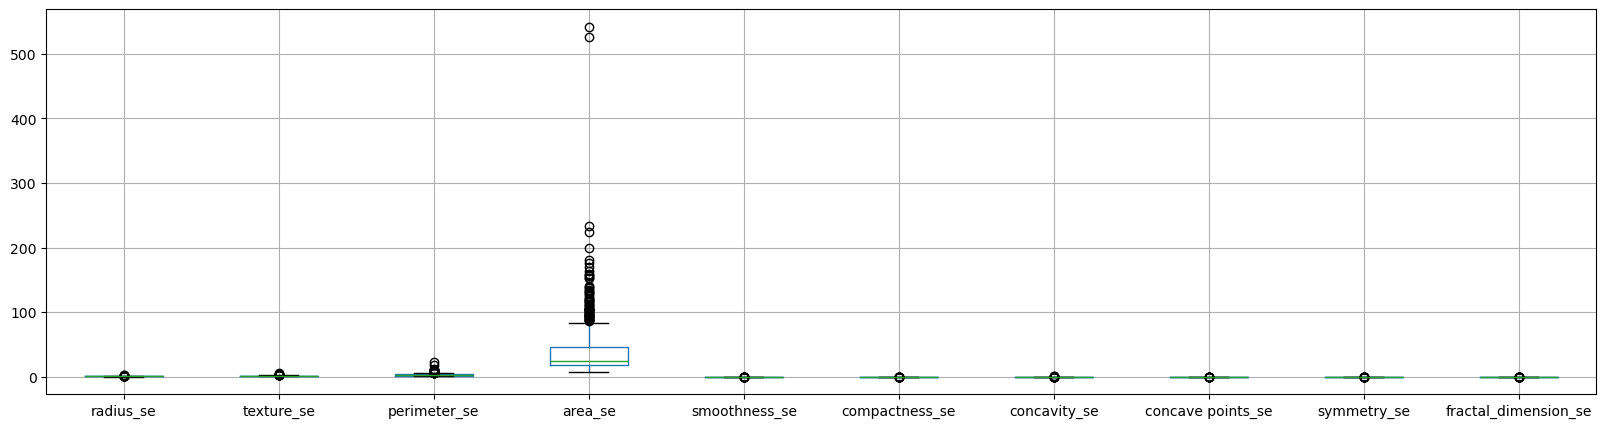

In [9]:
df.loc[:,'radius_se':'fractal_dimension_se'].boxplot(figsize=(20,5))
plt.show()

In [10]:
df.loc[:,'radius_worst':'fractal_dimension_worst'].describe()

,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


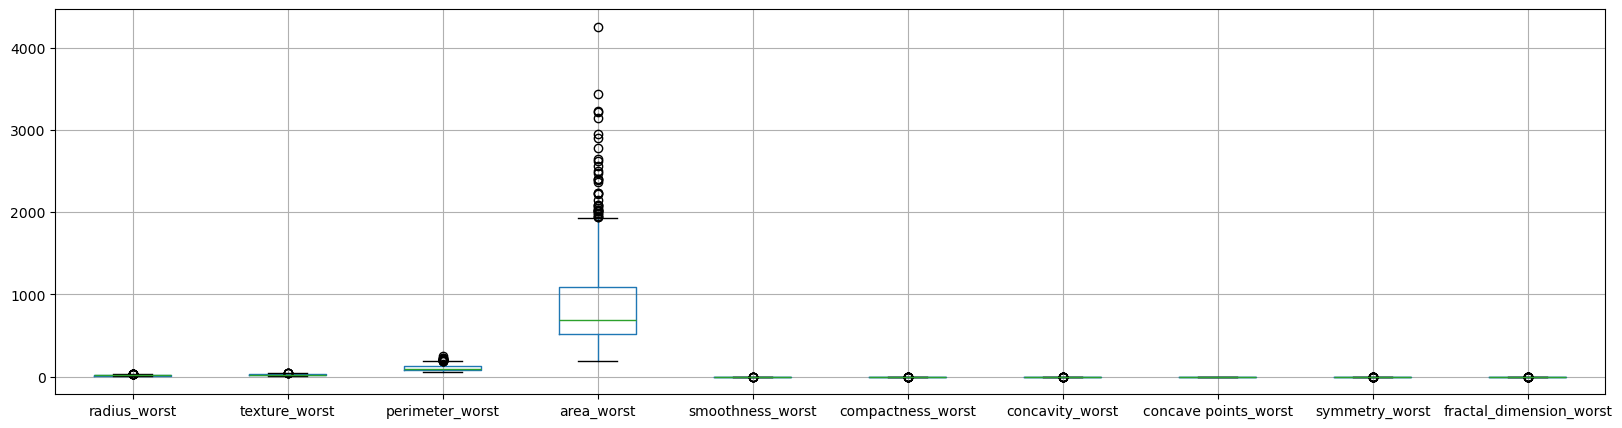

In [11]:
df.loc[:,'radius_worst':'fractal_dimension_worst'].boxplot(figsize=(20,5))
plt.show()

All attributes, except `concave points_worst`, have outliers. We will apply `RobustScaler` to them.

Let's also examine the histograms of all attribtes.

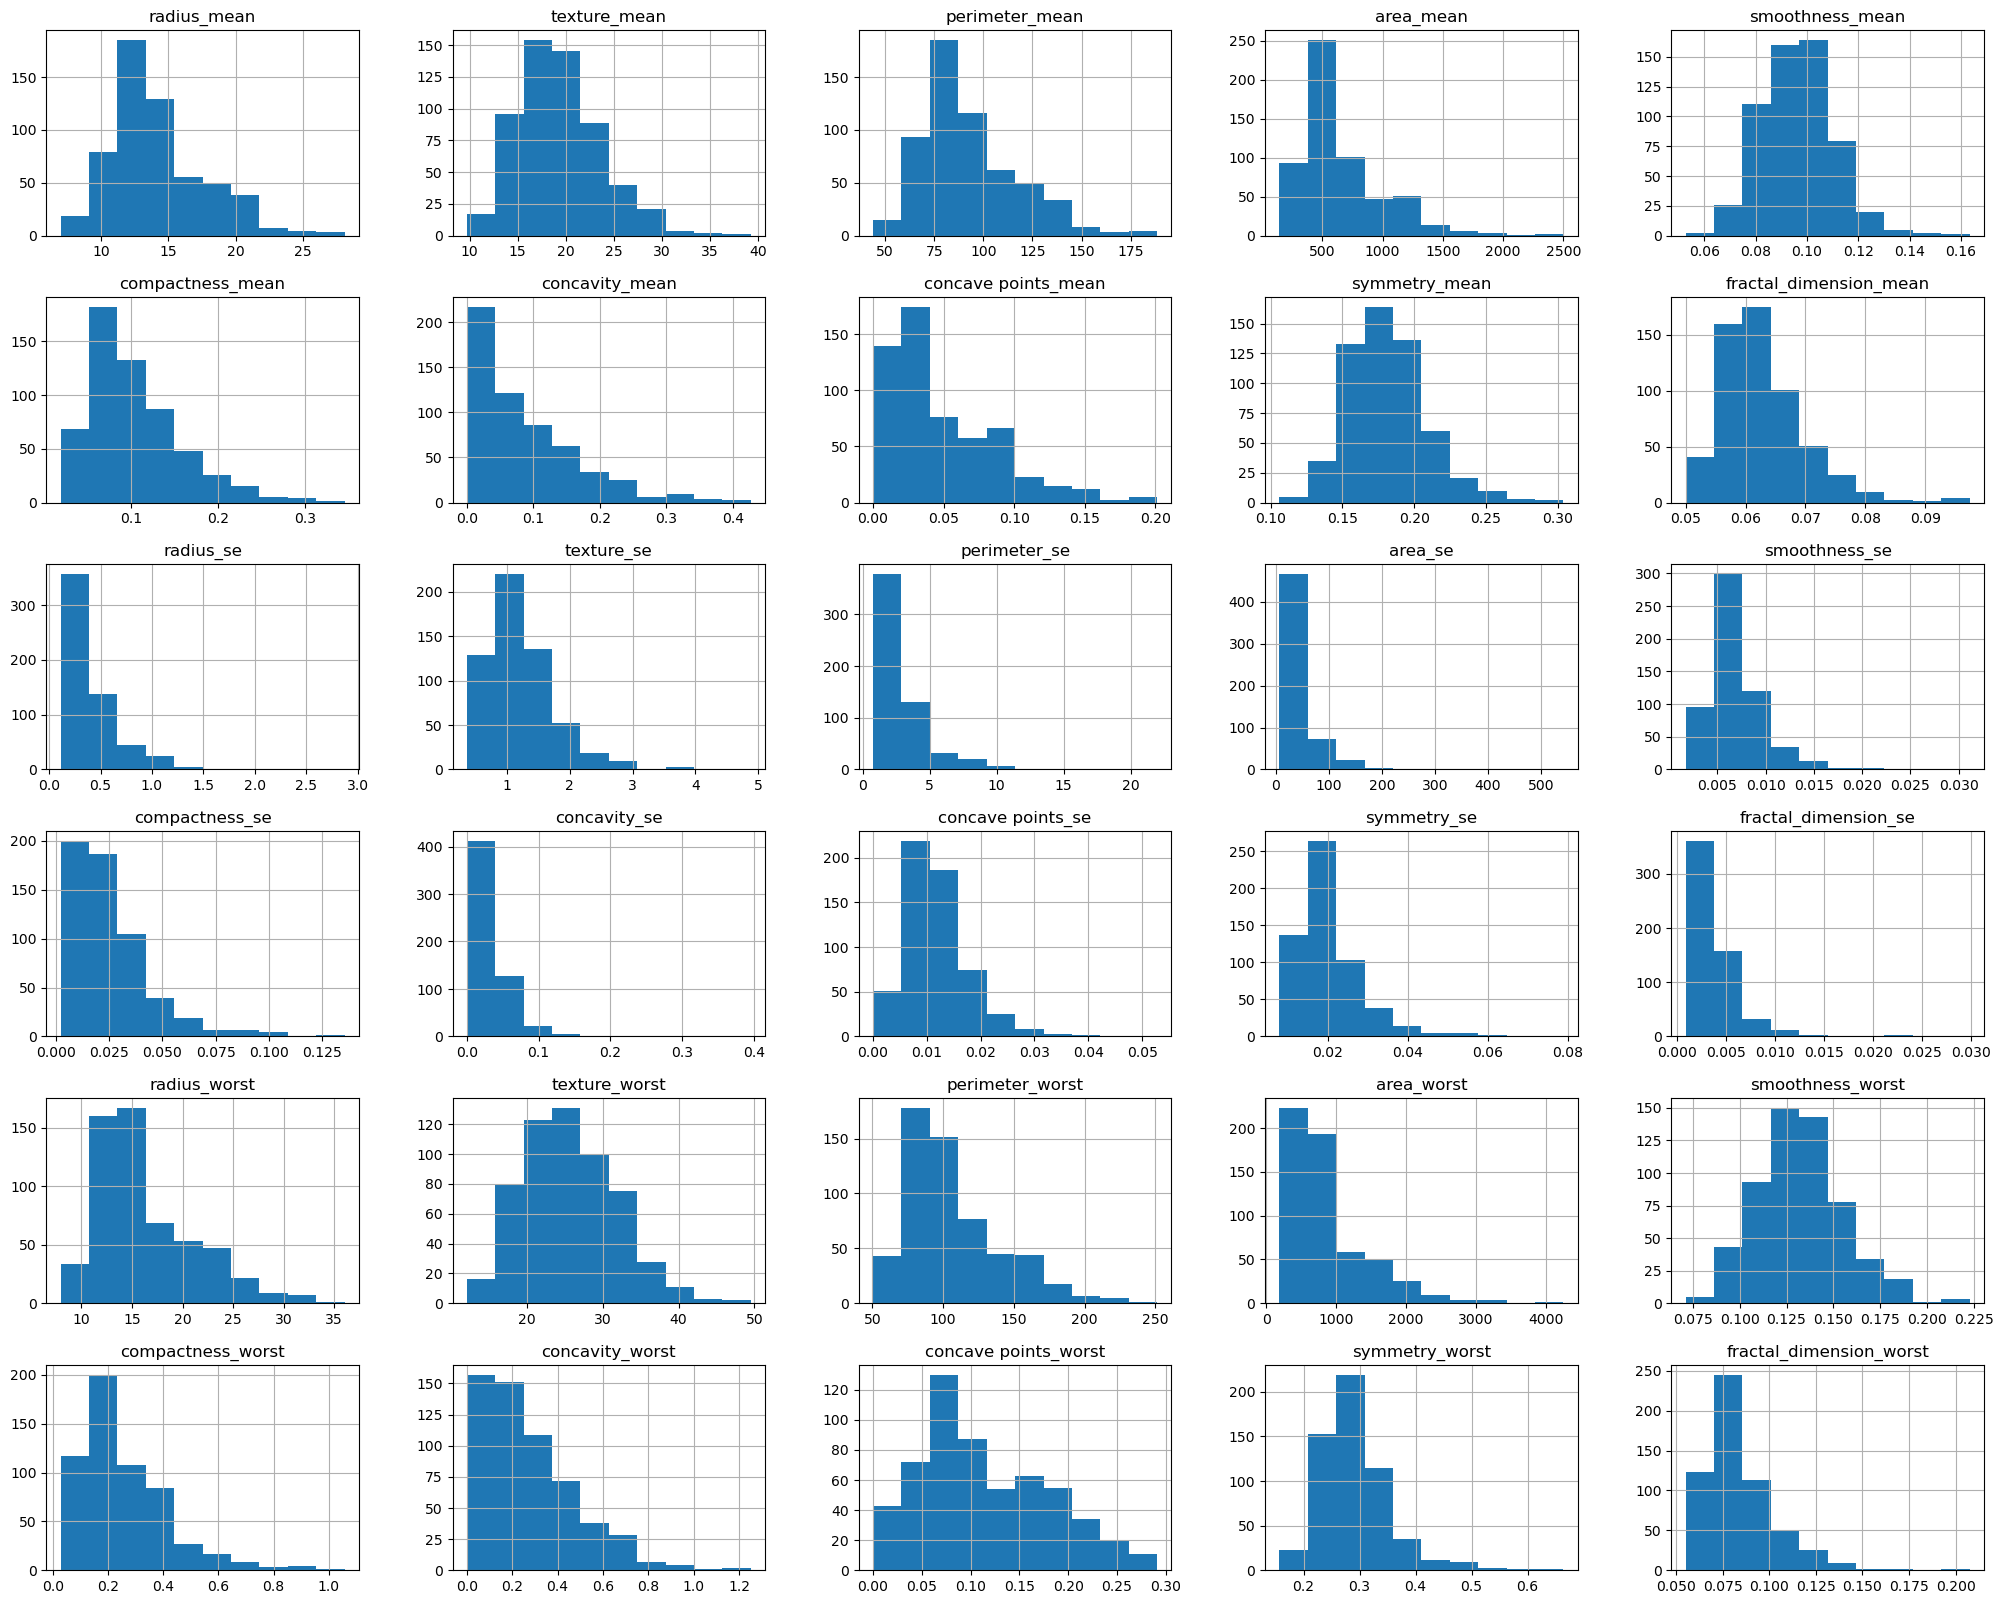

In [12]:
df.hist(bins=10, figsize=(25, 20));

It looks like all attributes are slightly skewed to the left and may benefit from a log transformation. All except the six attributes whose names start with concave and concavity do not contain 0s and we will apply log transformation to them. To the six attributes with 0s we will apply cubic root transformation instead. The goal here is also to demonstrate how different data preparation can be applied to different groups of attributes.

## 2. Data Preparation

First, we transform the `diagnosis` column to binary.

In [13]:
mapper = {'M': 1, 'B': 0}
df['diagnosis'] = df['diagnosis'].map(mapper).astype(int)
df['diagnosis'].value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64

Next we split the columns into a target *`y`* and predictors *`X`*.

In [14]:
y = df['diagnosis']
X = df.drop('diagnosis', axis=1)

We will attempt training SVM and Random Forest classifiers. We will tune their parameters, compare them and choose the best classifier for our problem. Here we will prepare a scikit-learn pipeline for data preparation (preprocessing pipeline), which we will apply later. The use of his pipelines ensures that preprocessing is applied separately to any training, validation and test dataset without data leakage.

First, we will partition the `predictors` into three groups, to which we will apply different data preparation.

In [15]:
# group 1
columns_no_outliers = ['concave points_worst']

In [16]:
# group 2
columns_outliers_and_zeros = ['concavity_mean','concave points_mean','concavity_se','concave points_se','concavity_worst'];

In [17]:
# group 3: all other predictors
columns_outliers_no_zeros = [item for item in list(X.columns) 
                             if item not in columns_no_outliers and item not in columns_outliers_and_zeros]

# verify the correct columns are selected
print(columns_outliers_no_zeros)
print(len(columns_outliers_no_zeros))

['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'symmetry_worst', 'fractal_dimension_worst']
24


Then we can build the **preprocessing pipeline** by using Pipeline and ColumnTransformer as follows.

In [18]:
outliers_no_zeros_pipeline = Pipeline(
    steps = [
        ("log_transform", FunctionTransformer(np.log)), 
        ("scaler", RobustScaler())
    ]
)

outliers_and_zeros_pipeline = Pipeline(
    steps = [
        ("cubic_root_transform", FunctionTransformer(np.cbrt)),
        ("scaler", RobustScaler())
    ]
)

preprocess_pipeline = ColumnTransformer(
    transformers = [
        ("outliers_no_zeros", outliers_no_zeros_pipeline, columns_outliers_no_zeros),    
        ("outliers_and_zeros", outliers_and_zeros_pipeline, columns_outliers_and_zeros),
        ("no_outliers", FunctionTransformer(np.cbrt), columns_no_outliers)
    ],
    remainder="passthrough" # note there are no remaining columns in this example
)

Now we split the dataset into a training set and a test set.

- The training set is used for model fitting and hyperparameter tuning.
- The test set is reserved for final evaluation only.

This separation prevents information leakage and ensures an unbiased estimate of generalisation performance.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, stratify=y)

The parameter `stratify=y` ensures both classes are represented in the same proportion in both the training and the test sets.

## 3. Model Training

Now, let's train a couple of classifiers by exploring various combinations of values of their hyperparameters.

Hyperparameters are tuned using 10-fold cross-validation on the training set. For each hyperparameter combination, the model is trained on 9 folds and validated on the remaining fold, repeated 10 times. Reported scores are the mean and standard deviation across folds.

The reported cross-validation scores are the mean and standard deviation across folds.

In [20]:
# Prepare a 10-fold stratified CV splitter (used for each classifier in this lab)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Evaluate multiple metrics during cross-validation (CV).
# The best model will be selected based on mean CV F1 score,
# while other metrics are reported for comparison.
scoring = {
    "Accuracy": "accuracy",
    "F1-score": "f1",
    "Precision": "precision",
    "Recall": "recall",
    "ROC_AUC": "roc_auc",
    "AP": "average_precision"
}

### 3.1. SVM

Next, we train an SVM classifier on the training set and tune its hyperparameters using cross-validation. To ensure proper preprocessing within each fold, we construct a pipeline that combines the preprocessing steps with the SVM classifier. The pipeline ensures that preprocessing is fitted only on the training portion of each fold and applied separately to the corresponding validation data, preventing data leakage.

In [21]:
# create the pipeline
pipe = Pipeline(steps=[('preprocess', preprocess_pipeline), ('svm', svm.SVC(probability=True))])

Let's visualise the pipeline.

In [22]:
set_config(display="diagram")
pipe

,steps,"[('preprocess', ...), ('svm', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('outliers_no_zeros', ...), ('outliers_and_zeros', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [23]:
# prepare a parameter grid
# note that __ can be used to specify the name of a parameter for a specific element in a pipeline
# note also that this is not an exhaustive list of the parameters of svm.SVC and their possible values
param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': [1, 0.1, 0.01, 0.001],
    'svm__kernel': ['rbf', 'linear', 'poly']
}

# Note that hyperparameters of the preprocessing transformers can also be included
# in the parameter grid. For simplicity, we do not tune them here.

svm_search = GridSearchCV(
    pipe,
    param_grid,
    n_jobs=-1,
    cv=cv,
    scoring=scoring,
    refit="F1-score",
    return_train_score=False
)

svm_search.fit(X_train, y_train)  # training happens here! SVM is trained len(grid) * folds times

print(f"Best CV F1 = {svm_search.best_score_:.3f}")
print("Best parameters: ", svm_search.best_params_)

# store the best params and best model for later use
SVM_best_params = svm_search.best_params_
SVM_best_model = svm_search.best_estimator_
SVM_best_cv_f1 = svm_search.best_score_


Best CV F1 = 0.976
Best parameters:  {'svm__C': 100, 'svm__gamma': 0.001, 'svm__kernel': 'rbf'}


To select a single best SVM model, we must specify one primary metric. Here, we use the F1 score.

- refit="f1": after cross-validation, GridSearchCV selects the hyperparameters that maximise the mean CV F1 score on the training set and then refits the model on the full training set using those optimal hyperparameters.

The resulting trained model is available as svm_search.best_estimator_.

### 3.2. Random Forest

Let's repeat the same experiment but with the Random Forest classifier.

In [24]:
# create the pipeline
pipe = Pipeline(steps=[('preprocess', preprocess_pipeline), ('rf', RandomForestClassifier())])

Let's visualise the pipeline.

In [25]:
set_config(display="diagram")
pipe

,steps,"[('preprocess', ...), ('rf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('outliers_no_zeros', ...), ('outliers_and_zeros', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Next, we train a Random Forest classifier and tune its hyperparameters using cross-validation.

In [26]:
# prepare a parameter grid
# note that __ can be used to specify the name of a parameter for a specific element in a pipeline
# note also that this is not an exhaustive list of the parameters of RandomForestClassifier and their possible values
param_grid = {
    'rf__n_estimators': [10, 20, 30],
    'rf__max_depth': [2, 4, 6, 8]
}

rf_search = GridSearchCV(
    pipe,
    param_grid,
    n_jobs=-1,
    cv=cv,
    scoring=scoring,
    refit="F1-score",
    return_train_score=False
)

rf_search.fit(X_train, y_train)
print(f"Best CV F1 = {rf_search.best_score_:.3f}")
print("Best parameters: ", rf_search.best_params_)

# store the best params and best model for later use
RF_best_params = rf_search.best_params_
RF_best_model = rf_search.best_estimator_
RF_best_cv_f1 = rf_search.best_score_


Best CV F1 = 0.946
Best parameters:  {'rf__max_depth': 8, 'rf__n_estimators': 20}


## 4. Cross-Validated Model Comparison (Training Set Only)

We now compare the best SVM and best Random Forest models using performance metrics obtained from 10-fold stratified cross-validation on the training set to select the final model.

We will:

1. Report the mean ± standard deviation of several metrics across CV folds.
2. Plot a bar chart showing the mean performance with error bars.
3. Plot ROC curves.
4. Plot Precision-Recall curves.
5. Select the best-performing model.

This procedure allows models to be compared rigorously without introducing information leakage from the test set.

### 4.1. Report Mean ± Standard Deviation of Several Metrics Across CV Folds

In [27]:
# Compute CV metrics (mean ± std) for the *best* SVM and RF models
models = {
    "SVM (best by F1)": SVM_best_model,
    "Random Forest (best by F1)": RF_best_model
}

cv_results = {}

for name, model in models.items():
    res = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )
    cv_results[name] = {m: res[f"test_{m}"] for m in scoring.keys()}

# Print a concise summary
for name, metrics_dict in cv_results.items():
    print("\n" + name)
    for m, vals in metrics_dict.items():
        print(f"  {m:9s}: mean={np.mean(vals):.3f}, std={np.std(vals):.3f}")



SVM (best by F1)
  Accuracy : mean=0.982, std=0.019
  F1-score : mean=0.976, std=0.027
  Precision: mean=0.989, std=0.023
  Recall   : mean=0.965, std=0.047
  ROC_AUC  : mean=0.996, std=0.012
  AP       : mean=0.996, std=0.009

Random Forest (best by F1)
  Accuracy : mean=0.960, std=0.024
  F1-score : mean=0.946, std=0.033
  Precision: mean=0.960, std=0.036
  Recall   : mean=0.935, std=0.061
  ROC_AUC  : mean=0.982, std=0.018
  AP       : mean=0.979, std=0.018


### 4.2. Plot a Bar Chart (Mean with Error Bars)

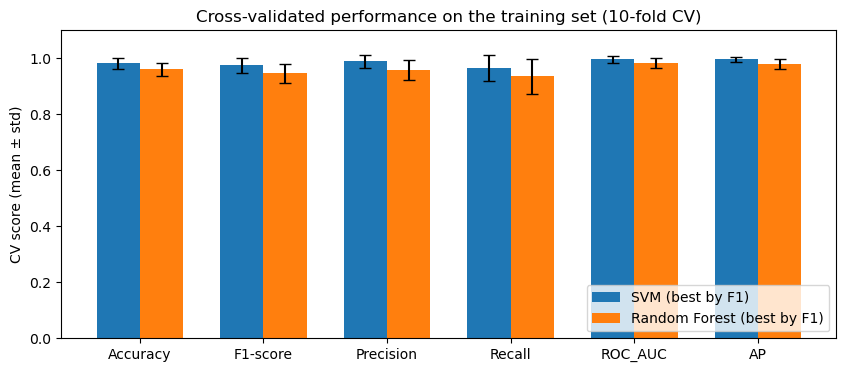

In [28]:
# Plot mean ± std for each metric
metric_names = list(scoring.keys())
labels = list(cv_results.keys())

means = {lab: [np.mean(cv_results[lab][m]) for m in metric_names] for lab in labels}
stds  = {lab: [np.std(cv_results[lab][m]) for m in metric_names] for lab in labels}

x = np.arange(len(metric_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - width/2, means[labels[0]], width, yerr=stds[labels[0]], capsize=4, label=labels[0])
ax.bar(x + width/2, means[labels[1]], width, yerr=stds[labels[1]], capsize=4, label=labels[1])

ax.set_xticks(x)
ax.set_xticklabels(metric_names, rotation=0)
ax.set_ylim(0, 1.1)
ax.set_ylabel("CV score (mean ± std)")
ax.set_title("Cross-validated performance on the training set (10-fold CV)")
ax.legend(loc="lower right")
plt.show()


 Error bars represent ±1 standard deviation of the metric across the 10 cross-validation folds.

### 4.3. ROC Curves from Out-of-Fold Predictions (Training Set)

Instead of averaging ROC curves per fold (which requires interpolation), we compute a single ROC curve using *out-of-fold* predicted probabilities for each training example. That is, each example is scored by a model that was not trained on it. This allows us to plot ROC and Precision-Recall curves based solely on training data, without using the test set.

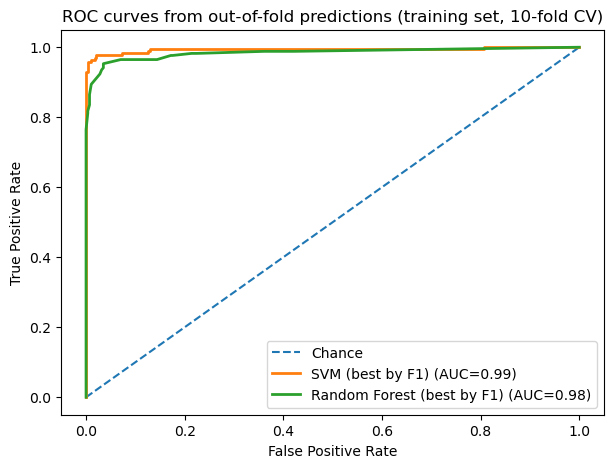

In [29]:
# Out-of-fold ROC curves for the two best models (training set only)
plt.figure(figsize=(7, 5))
plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")

for name, model in models.items():
    # Out-of-fold probability for class 1 (each point predicted by a model that did not train on it)
    oof_proba = cross_val_predict(model, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]

    fpr, tpr, _ = roc_curve(y_train, oof_proba)
    auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={auc_val:.2f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves from out-of-fold predictions (training set, 10-fold CV)")
plt.legend(loc="lower right")
plt.show()


ROC curves illustrate the trade-off between True Positive Rate and False Positive Rate across decision thresholds. A larger ROC AUC indicates stronger discrimination between the two classes, meaning the model more effectively distinguishes positive from negative cases. Curves closer to the top-left corner represent better overall performance.

### 4.4. Precision-Recall Curves from Out-of-Fold Predictions (Training Set)

For imbalanced problems, Precision-Recall curves can be more informative than ROC curves.  
We compute Precision-Recall curves and Average Precision (AP) from out-of-fold predictions. AP is a single number that summarises the Precision-Recall curve by averaging precision values as recall increases across thresholds.


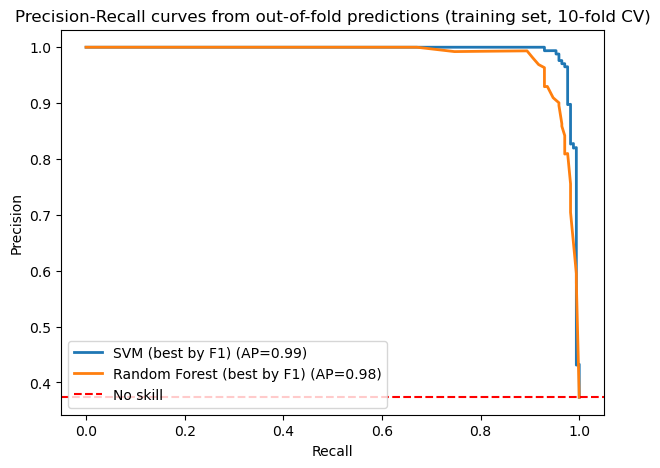

In [30]:
plt.figure(figsize=(7, 5))

for name, model in models.items():
    oof_proba = cross_val_predict(model, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
    prec, rec, _ = precision_recall_curve(y_train, oof_proba)
    ap = average_precision_score(y_train, oof_proba)
    plt.plot(rec, prec, lw=2, label=f"{name} (AP={ap:.2f})")

plt.axhline(y=y_train.mean(), color='red', linestyle='--', label='No skill')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curves from out-of-fold predictions (training set, 10-fold CV)")
plt.legend(loc="lower left")
plt.show()


Precision-Recall curves illustrate how precision changes as recall increases across decision thresholds. A higher AP indicates a stronger overall precision-recall trade-off and better identification of positive cases. The horizontal dashed line represents the performance of a random classifier, equal to the proportion of positive cases in the dataset; curves above this line indicate meaningful predictive performance.

### 4.5. Final Model Selection

The model with the highest mean cross-validated F1 score is selected. Note that the selected model is trained on the full training set (using the optimal hyperparameters).

In [31]:
# Choose the best classifier based on cross-validated F1 on the training set
if SVM_best_cv_f1 >= RF_best_cv_f1:
    best_name = "SVM"
    best_model = SVM_best_model
    best_cv_f1 = SVM_best_cv_f1
else:
    best_name = "Random Forest"
    best_model = RF_best_model
    best_cv_f1 = RF_best_cv_f1

print(f"Chosen model based on 10-fold CV F1 on the training set: {best_name} (mean CV F1 = {best_cv_f1:.3f})")

Chosen model based on 10-fold CV F1 on the training set: SVM (mean CV F1 = 0.976)


## 5. Final Evaluation on the Test Set

Now we can evaluate the selected best model on the held-out test dataset and report its performance (accuracy, precision, recall, etc.).

**Important:** the test set is used *only once* for final evaluation. Model selection (choosing between SVM vs Random Forest and tuning hyperparameters) is done using cross-validation on the training data.


### 5.1. Evaluation Function

The evaluation function below evaluates a model on a test dataset. Note that the preprocessing pipeline is automatically applied to the test set.

In [32]:
# model - a trained binary probabilistic classification model;
#         it is assumed that there are two classes: 0 and 1
#         and the classifier can output probability scores for class 1 via predict_proba

def evaluate_model(X_eval, y_eval, model):
    # predicted probabilities for class 1
    probabilities = model.predict_proba(X_eval)[:, 1]

    # predicted class labels
    predicted = model.predict(X_eval)

    results = {
        "confusion_matrix": confusion_matrix(y_eval, predicted),
        "accuracy": accuracy_score(y_eval, predicted),
        "precision": precision_score(y_eval, predicted, zero_division=0),
        "recall": recall_score(y_eval, predicted, zero_division=0),
        "f1": f1_score(y_eval, predicted, zero_division=0)
    }

    fpr, tpr, _ = roc_curve(y_eval, probabilities)
    results["fpr"] = fpr
    results["tpr"] = tpr
    results["auc"] = auc(fpr, tpr)

    prc_precision, prc_recall, _ = precision_recall_curve(y_eval, probabilities)
    results["prc_precision"] = prc_precision
    results["prc_recall"] = prc_recall
    results["ap"] = average_precision_score(y_eval, probabilities)

    return results


Now we will use the function above to evaluate the selected best model. We report:
- Confusion matrix,
- Accuracy, Precision, Recall, F1 score,
- ROC curve and ROC AUC,
- Precision-Recall curve and Average Precision.

These results provide both threshold-dependent and threshold-independent evaluation of the final model.

In [33]:
# Final evaluation on the held-out test set (used once for reporting)
test_results = evaluate_model(X_test, y_test, best_model)

### 5.2. Display the Confusion Matrix for the Test Set

The confusion matrix summarises predictions at the default decision threshold (0.5). From this matrix, we can directly compute accuracy, precision, recall, and specificity.

In [34]:
cm_df = pd.DataFrame(
    test_results["confusion_matrix"],
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

print("Confusion Matrix (Test Set):")
display(cm_df)

Confusion Matrix (Test Set):


,Predicted 0,Predicted 1
Actual 0,71,1
Actual 1,2,40


### 5.3. Plot Metrics for Class 1

Now we plot the accuracy, precision, recall and F1-score for class 1.

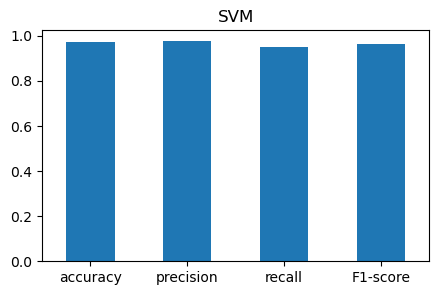

In [35]:
metrics = np.array([test_results["accuracy"], test_results["precision"], test_results["recall"], test_results["f1"]])
index = ['accuracy', 'precision', 'recall', 'F1-score']
df_metrics = pd.DataFrame({best_name: metrics}, index=index)
df_metrics.plot.bar(rot=0, figsize=(5, 3), legend=False, title=f"{best_name}")
plt.show()

### 5.4. Plot ROC Curve for Class 1

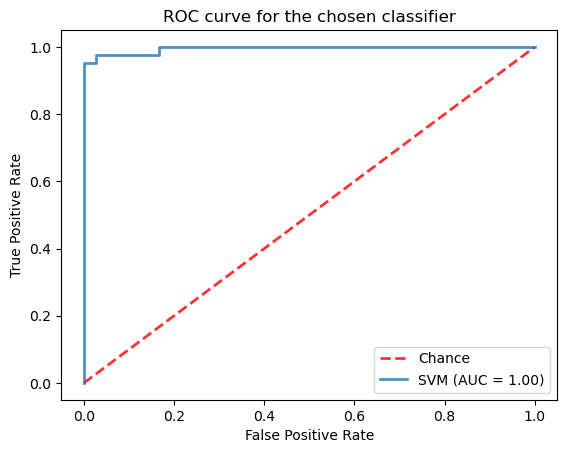

In [36]:
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance', alpha=0.8)
plt.plot(test_results["fpr"], test_results["tpr"], lw=2, label=f'{best_name} (AUC = {test_results["auc"]:0.2f})', alpha=0.8)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve for the chosen classifier')
plt.legend(loc="lower right")
plt.show()


The ROC curve above confirms that the model performs significantly better than a random guess (the red dashed `no skill` line).

### 5.5. Plot Precision-Recall Curve for Class 1

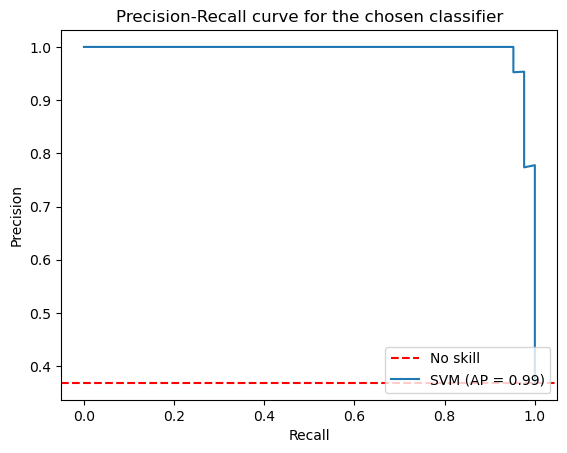

In [37]:
plt.axhline(y=y_test.mean(), color='red', linestyle='--', label='No skill')
plt.plot(test_results["prc_recall"], test_results["prc_precision"], label=f'{best_name} (AP = {test_results["ap"]:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curve for the chosen classifier')
plt.legend(loc="lower right")
plt.show()

The Precision-Recall curve above also confirms that the model performs significantly better than a random guess (the red dashed `no skill` line).

## 6. Export the Final Model

We can store the best-performing model on disk so that it can later be deployed.

In [38]:
filename = 'best_model.sav'
pickle.dump(best_model, open(filename, 'wb'))